In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

ModuleNotFoundError: No module named 'numpy'

# Flood Risk Prediction and Spatial Mapping

## EE769 Introduction to Machine Learning Project
submitted By 
- Mahesh Thadepalli (25M0314)
- Aayush Guptha (25M0140)
- Muhammed Nasimudheenn(25M0309)

## Objectives
- To develop a machine learning framework for predicting rainfall-driven flood risk at the subdivision–month level.
- To incorporate temporal features (such as lagged rainfall and rolling averages) in order to capture the influence of recent rainfall patterns on flood risk.
- To compare simple rule-based baselines with more complex machine learning models, evaluating whether increased model complexity leads to meaningful performance improvements.
- To generate and analyze probabilistic predictions and spatial flood-risk visualizations across India, enhancing interpretability and supporting data-driven decision-making.


## Motivation

The motivations behind this project are, first, floods are a major natural hazard in India, and improving the ability to predict high risk periods can support better disaster preparedness and planning. Since rainfall is a key driver of flooding and historical data is widely available, it provides a strong foundation for building predictive models.

Second, the project aims to critically evaluate the value of machine learning models. By comparing them with a simple rule-based threshold approach, it investigates whether increased model complexity actually leads to better performance. Additionally, the project emphasizes interpretability and practical usefulness through probabilistic predictions and spatial mapping, making the results more actionable for real-world decision-making

## Problem Setup

The project formulates flood risk prediction as a binary classification problem, where each data point represents a subdivision–month instance. Since actual flood occurrence data is unavailable, a proxy label based on extreme rainfall (above the 80th percentile within each subdivision) is used to define high flood risk. The model takes as input current rainfall along with temporal features such as lagged rainfall, rolling averages, and rainfall changes to capture time dependent patterns. The task is evaluated using a time based train-test split, ensuring that predictions are made on future data, making the setup realistic for forecasting.



In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

from sklearn.base import clone
from sklearn.calibration import calibration_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    auc,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)


ModuleNotFoundError: No module named 'numpy'

## Data Preparation

We keep the dataset in long format because temporal feature engineering is easier when each row represents one subdivision-month observation.


In [ ]:
df = pd.read_csv('/kaggle/input/datasets/maheshtadepalli02/rainfall-dataset/Sub_Division_IMD_2017.csv')
print("Original shape:", df.shape)
df.head()


Original shape: (4188, 19)


,SUBDIVISION,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANNUAL,JF,MAM,JJAS,OND
0,Andaman & Nicobar Islands,1901,49.2,87.1,29.2,2.3,528.8,517.5,365.1,481.1,332.6,388.5,558.2,33.6,3373.2,136.3,560.3,1696.3,980.3
1,Andaman & Nicobar Islands,1902,0.0,159.8,12.2,0.0,446.1,537.1,228.9,753.7,666.2,197.2,359.0,160.5,3520.7,159.8,458.3,2185.9,716.7
2,Andaman & Nicobar Islands,1903,12.7,144.0,0.0,1.0,235.1,479.9,728.4,326.7,339.0,181.2,284.4,225.0,2957.4,156.7,236.1,1874.0,690.6
3,Andaman & Nicobar Islands,1904,9.4,14.7,0.0,202.4,304.5,495.1,502.0,160.1,820.4,222.2,308.7,40.1,3079.6,24.1,506.9,1977.6,571.0
4,Andaman & Nicobar Islands,1905,1.3,0.0,3.3,26.9,279.5,628.7,368.7,330.5,297.0,260.7,25.4,344.7,2566.7,1.3,309.7,1624.9,630.8


In [ ]:
print(df.columns.tolist())


['SUBDIVISION', 'YEAR', 'JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC', 'ANNUAL', 'JF', 'MAM', 'JJAS', 'OND']


In [ ]:
df = df.drop(columns=['ANNUAL', 'JF', 'MAM', 'JJAS', 'OND'], errors='ignore')

df_long = df.melt(
    id_vars=['SUBDIVISION', 'YEAR'],
    var_name='MONTH',
    value_name='RAINFALL'
).dropna()

month_map = {
    'JAN': 1, 'FEB': 2, 'MAR': 3, 'APR': 4,
    'MAY': 5, 'JUN': 6, 'JUL': 7, 'AUG': 8,
    'SEP': 9, 'OCT': 10, 'NOV': 11, 'DEC': 12
}

df_long['MONTH'] = df_long['MONTH'].map(month_map)
df_long = df_long.sort_values(['SUBDIVISION', 'YEAR', 'MONTH']).reset_index(drop=True)

print("Reshaped long-format shape:", df_long.shape)
df_long.head()


Reshaped long-format shape: (50186, 4)


,SUBDIVISION,YEAR,MONTH,RAINFALL
0,Andaman & Nicobar Islands,1901,1,49.2
1,Andaman & Nicobar Islands,1901,2,87.1
2,Andaman & Nicobar Islands,1901,3,29.2
3,Andaman & Nicobar Islands,1901,4,2.3
4,Andaman & Nicobar Islands,1901,5,528.8


## Label Definition

- The target used here is a rainfall based flood risk proxy, not observed flood event ground truth.

- `FLOOD = 1` means rainfall in that subdivision-month is above the subdivision wise 80th percentile in the historical data.  
- This gives us a practical classification target for experimentation, but it should be interpreted as high rainfall flood risk, not confirmed flood occurrence.


In [ ]:
df_long['FLOOD'] = (
    df_long.groupby('SUBDIVISION')['RAINFALL']
    .transform(lambda x: (x > x.quantile(0.8)).astype(int))
)

print("Flood label distribution:")
print(df_long['FLOOD'].value_counts())
df_long.head()


Flood label distribution:
FLOOD
0    40146
1    10040
Name: count, dtype: int64


,SUBDIVISION,YEAR,MONTH,RAINFALL,FLOOD
0,Andaman & Nicobar Islands,1901,1,49.2,0
1,Andaman & Nicobar Islands,1901,2,87.1,0
2,Andaman & Nicobar Islands,1901,3,29.2,0
3,Andaman & Nicobar Islands,1901,4,2.3,0
4,Andaman & Nicobar Islands,1901,5,528.8,1


## Exploratory Data Analysis


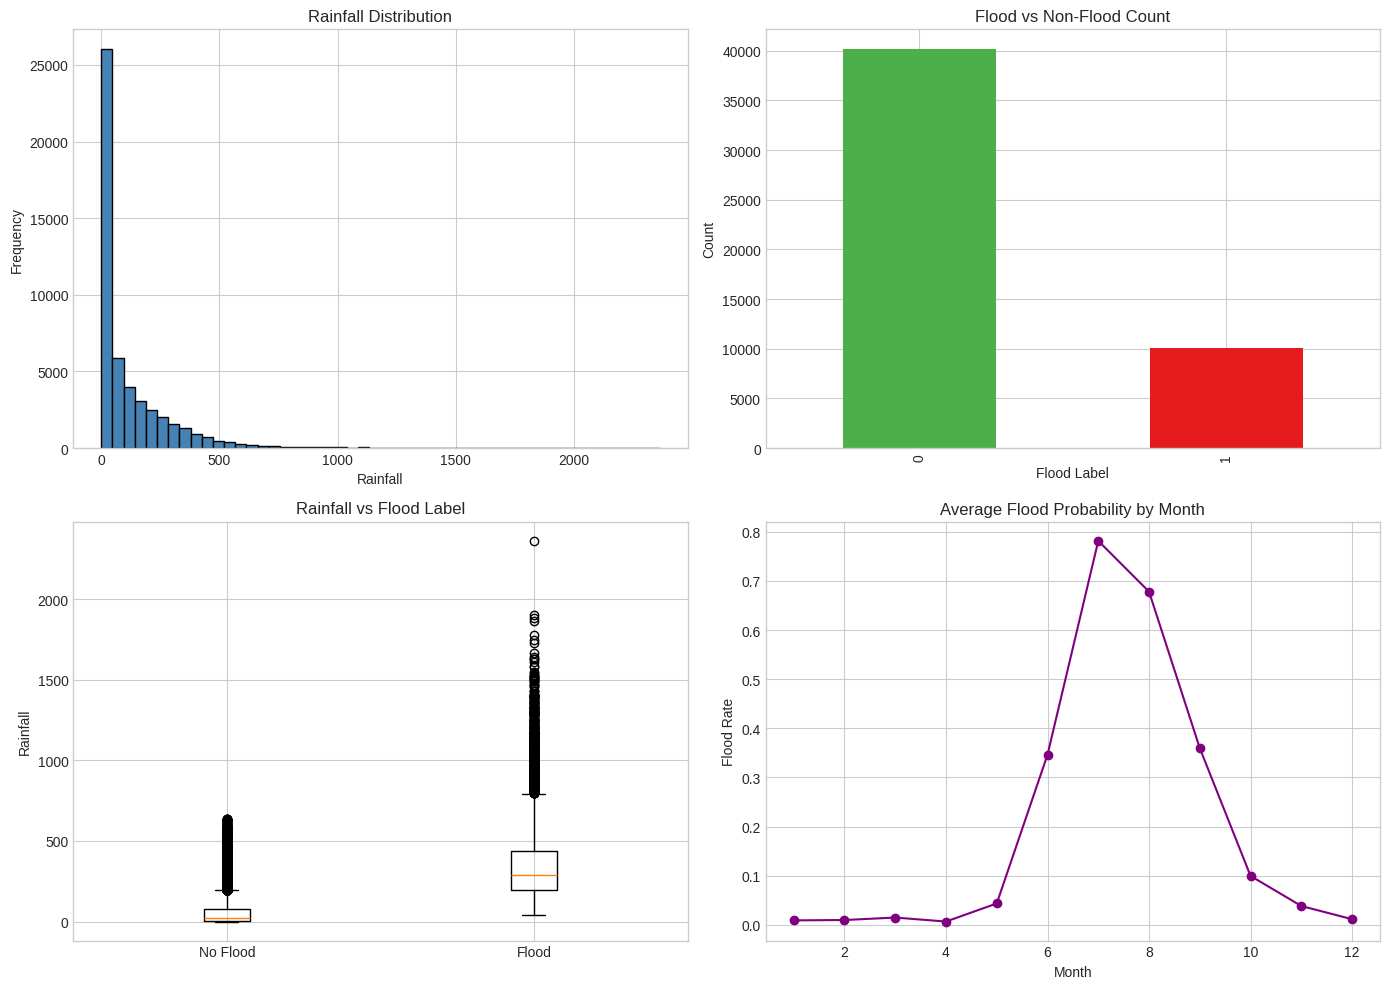

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(df_long['RAINFALL'], bins=50, color='steelblue', edgecolor='black')
axes[0, 0].set_title("Rainfall Distribution")
axes[0, 0].set_xlabel("Rainfall")
axes[0, 0].set_ylabel("Frequency")

df_long['FLOOD'].value_counts().sort_index().plot(kind='bar', ax=axes[0, 1], color=['#4daf4a', '#e41a1c'])
axes[0, 1].set_title("Flood vs Non-Flood Count")
axes[0, 1].set_xlabel("Flood Label")
axes[0, 1].set_ylabel("Count")

axes[1, 0].boxplot([
    df_long[df_long['FLOOD'] == 0]['RAINFALL'],
    df_long[df_long['FLOOD'] == 1]['RAINFALL']
], labels=['No Flood', 'Flood'])
axes[1, 0].set_title("Rainfall vs Flood Label")
axes[1, 0].set_ylabel("Rainfall")

df_long.groupby('MONTH')['FLOOD'].mean().plot(marker='o', ax=axes[1, 1], color='purple')
axes[1, 1].set_title("Average Flood Probability by Month")
axes[1, 1].set_xlabel("Month")
axes[1, 1].set_ylabel("Flood Rate")

plt.tight_layout()
plt.show()


## Temporal Feature Engineering

Flood risk is a time dependent problem, so we add lag and rolling history features within each subdivision.

- Lag features capture rainfall in recent previous months.
- Rolling features summarize short term rainfall accumulation.
- Rainfall change measures whether conditions are intensifying quickly.

These features improve realism compared with using only the current month and year.


In [ ]:
le = LabelEncoder()
df_long['SUBDIVISION_ENC'] = le.fit_transform(df_long['SUBDIVISION'])
df_long['MONSOON'] = df_long['MONTH'].isin([6, 7, 8, 9]).astype(int)

grouped = df_long.groupby('SUBDIVISION')['RAINFALL']
df_long['RAINFALL_LAG_1'] = grouped.shift(1)
df_long['RAINFALL_LAG_2'] = grouped.shift(2)
df_long['RAINFALL_LAG_3'] = grouped.shift(3)
df_long['RAINFALL_LAG_12'] = grouped.shift(12)
df_long['RAINFALL_ROLL_3'] = grouped.transform(lambda x: x.shift(1).rolling(window=3).mean())
df_long['RAINFALL_ROLL_6'] = grouped.transform(lambda x: x.shift(1).rolling(window=6).mean())
df_long['RAINFALL_CHANGE_1'] = df_long['RAINFALL'] - df_long['RAINFALL_LAG_1']

feature_columns = [
    'RAINFALL',
    'MONTH',
    'YEAR',
    'SUBDIVISION_ENC',
    'MONSOON',
    'RAINFALL_LAG_1',
    'RAINFALL_LAG_2',
    'RAINFALL_LAG_3',
    'RAINFALL_LAG_12',
    'RAINFALL_ROLL_3',
    'RAINFALL_ROLL_6',
    'RAINFALL_CHANGE_1'
]

df_model = df_long.dropna(subset=feature_columns).copy()
print("Shape after temporal feature engineering:", df_model.shape)
df_model[[
    'SUBDIVISION', 'YEAR', 'MONTH', 'RAINFALL',
    'RAINFALL_LAG_1', 'RAINFALL_LAG_12',
    'RAINFALL_ROLL_3', 'RAINFALL_ROLL_6', 'RAINFALL_CHANGE_1'
]].head(10)


Shape after temporal feature engineering: (49754, 14)


,SUBDIVISION,YEAR,MONTH,RAINFALL,RAINFALL_LAG_1,RAINFALL_LAG_12,RAINFALL_ROLL_3,RAINFALL_ROLL_6,RAINFALL_CHANGE_1
12,Andaman & Nicobar Islands,1902,1,0.0,33.6,49.2,326.766667,359.850000,-33.6
13,Andaman & Nicobar Islands,1902,2,159.8,0.0,87.1,197.266667,299.000000,159.8
14,Andaman & Nicobar Islands,1902,3,12.2,159.8,29.2,64.466667,245.450000,-147.6
15,Andaman & Nicobar Islands,1902,4,0.0,12.2,2.3,57.333333,192.050000,-12.2
16,Andaman & Nicobar Islands,1902,5,446.1,0.0,528.8,57.333333,127.300000,446.1
17,Andaman & Nicobar Islands,1902,6,537.1,446.1,517.5,152.766667,108.616667,91.0
18,Andaman & Nicobar Islands,1902,7,228.9,537.1,365.1,327.733333,192.533333,-308.2
19,Andaman & Nicobar Islands,1902,8,753.7,228.9,481.1,404.033333,230.683333,524.8
20,Andaman & Nicobar Islands,1902,9,666.2,753.7,332.6,506.566667,329.666667,-87.5
21,Andaman & Nicobar Islands,1902,10,197.2,666.2,388.5,549.600000,438.666667,-469.0


In [ ]:
sample_subdivision = 'Assam & Meghalaya'
df_model[df_model['SUBDIVISION'] == sample_subdivision][[
    'SUBDIVISION', 'YEAR', 'MONTH', 'RAINFALL',
    'RAINFALL_LAG_1', 'RAINFALL_LAG_2', 'RAINFALL_LAG_3',
    'RAINFALL_LAG_12', 'RAINFALL_ROLL_3', 'RAINFALL_ROLL_6'
]].head(12)


,SUBDIVISION,YEAR,MONTH,RAINFALL,RAINFALL_LAG_1,RAINFALL_LAG_2,RAINFALL_LAG_3,RAINFALL_LAG_12,RAINFALL_ROLL_3,RAINFALL_ROLL_6
2511,Assam & Meghalaya,1902,1,9.3,1.2,115.6,163.7,27.1,93.500000,244.433333
2512,Assam & Meghalaya,1902,2,10.2,9.3,1.2,115.6,19.5,42.033333,174.216667
2513,Assam & Meghalaya,1902,3,105.6,10.2,9.3,1.2,30.6,6.900000,98.566667
2514,Assam & Meghalaya,1902,4,350.0,105.6,10.2,9.3,223.0,41.700000,67.600000
2515,Assam & Meghalaya,1902,5,262.1,350.0,105.6,10.2,207.0,155.266667,98.650000
2516,Assam & Meghalaya,1902,6,620.7,262.1,350.0,105.6,524.9,239.233333,123.066667
2517,Assam & Meghalaya,1902,7,510.8,620.7,262.1,350.0,430.6,410.933333,226.316667
2518,Assam & Meghalaya,1902,8,536.0,510.8,620.7,262.1,464.1,464.533333,309.900000
2519,Assam & Meghalaya,1902,9,441.3,536.0,510.8,620.7,291.4,555.833333,397.533333
2520,Assam & Meghalaya,1902,10,97.0,441.3,536.0,510.8,163.7,496.033333,453.483333


## Train/Test Split

The main evaluation uses a time based split  so the model is trained on earlier years and evaluated on later years.This is more defensible for a temporal forecasting problem than a random split.


In [ ]:
train_df = df_model[(df_model['YEAR'] >= 1902) & (df_model['YEAR'] <= 2010)].copy()
test_df = df_model[(df_model['YEAR'] >= 2011) & (df_model['YEAR'] <= 2017)].copy()

X_train = train_df[feature_columns]
y_train = train_df['FLOOD']
X_test = test_df[feature_columns]
y_test = test_df['FLOOD']

print("Train years:", train_df['YEAR'].min(), "to", train_df['YEAR'].max())
print("Test years:", test_df['YEAR'].min(), "to", test_df['YEAR'].max())
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)


Train years: 1902 to 2010
Test years: 2011 to 2017
Train shape: (46731, 12) Test shape: (3023, 12)


## Baselines and Models

We compare four approaches:
1. A simple rule based baseline using subdivision-wise rainfall thresholds learned from training data only.
2. Logistic Regression
3. Decision Tree
4. Random Forest

This comparison reveals whether more flexible models truly outperform simple rules.



In [ ]:
train_thresholds = train_df.groupby('SUBDIVISION')['RAINFALL'].quantile(0.8)
global_threshold = train_df['RAINFALL'].quantile(0.8)

def rule_based_predict(frame):
    thresholds = frame['SUBDIVISION'].map(train_thresholds).fillna(global_threshold)
    preds = (frame['RAINFALL'] > thresholds).astype(int)
    probs = (frame['RAINFALL'] / thresholds.replace(0, np.nan)).clip(lower=0, upper=1.5).fillna(0) / 1.5
    return preds, probs.clip(0, 1)


In [ ]:
models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=2000, random_state=42))
    ]),
    'Decision Tree': DecisionTreeClassifier(max_depth=8, min_samples_leaf=10, random_state=42),
    'Random Forest': RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    )
}

results = []
predictions = {}

rule_preds, rule_probs = rule_based_predict(test_df)
predictions['Rule-Based Baseline'] = {
    'preds': np.asarray(rule_preds),
    'probs': np.asarray(rule_probs)
}

results.append({
    'Model': 'Rule-Based Baseline',
    'Accuracy': accuracy_score(y_test, rule_preds),
    'Precision': precision_score(y_test, rule_preds, zero_division=0),
    'Recall': recall_score(y_test, rule_preds, zero_division=0),
    'F1 Score': f1_score(y_test, rule_preds, zero_division=0),
    'ROC-AUC': roc_auc_score(y_test, rule_probs)
})

fitted_models = {}
for name, model in models.items():
    fitted = clone(model)
    fitted.fit(X_train, y_train)
    preds = fitted.predict(X_test)
    probs = fitted.predict_proba(X_test)[:, 1]
    fitted_models[name] = fitted
    predictions[name] = {'preds': preds, 'probs': probs}
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds, zero_division=0),
        'Recall': recall_score(y_test, preds, zero_division=0),
        'F1 Score': f1_score(y_test, preds, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, probs)
    })

results_df = pd.DataFrame(results).sort_values(
    by=['F1 Score', 'ROC-AUC', 'Accuracy'],
    ascending=False
).reset_index(drop=True)

results_df


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Rule-Based Baseline,0.997684,0.998155,0.989031,0.993572,0.999986
1,Decision Tree,0.967251,0.900000,0.921389,0.910569,0.989995
2,Random Forest,0.963612,0.890877,0.910420,0.900542,0.992907
3,Logistic Regression,0.934833,0.828947,0.806216,0.817424,0.973974


In [ ]:
best_model_name = results_df.loc[0, 'Model']
print("Best model on the time-based split:", best_model_name)
results_df.style.format({
    'Accuracy': '{:.4f}',
    'Precision': '{:.4f}',
    'Recall': '{:.4f}',
    'F1 Score': '{:.4f}',
    'ROC-AUC': '{:.4f}'
})


Best model on the time-based split: Rule-Based Baseline


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Rule-Based Baseline,0.9977,0.9982,0.9890,0.9936,1.0000
1,Decision Tree,0.9673,0.9000,0.9214,0.9106,0.9900
2,Random Forest,0.9636,0.8909,0.9104,0.9005,0.9929
3,Logistic Regression,0.9348,0.8289,0.8062,0.8174,0.9740


In [ ]:
random_X_train, random_X_test, random_y_train, random_y_test = train_test_split(
    df_model[feature_columns],
    df_model['FLOOD'],
    test_size=0.2,
    random_state=42,
    stratify=df_model['FLOOD']
)

random_rf = clone(models['Random Forest'])
random_rf.fit(random_X_train, random_y_train)
random_rf_preds = random_rf.predict(random_X_test)
random_rf_probs = random_rf.predict_proba(random_X_test)[:, 1]

comparison_split_df = pd.DataFrame([
    {
        'Evaluation Split': 'Time-based',
        'Accuracy': accuracy_score(y_test, predictions['Random Forest']['preds']),
        'F1 Score': f1_score(y_test, predictions['Random Forest']['preds']),
        'ROC-AUC': roc_auc_score(y_test, predictions['Random Forest']['probs'])
    },
    {
        'Evaluation Split': 'Random',
        'Accuracy': accuracy_score(random_y_test, random_rf_preds),
        'F1 Score': f1_score(random_y_test, random_rf_preds),
        'ROC-AUC': roc_auc_score(random_y_test, random_rf_probs)
    }
])

comparison_split_df


,Evaluation Split,Accuracy,F1 Score,ROC-AUC
0,Time-based,0.963612,0.900542,0.992907
1,Random,0.968747,0.921046,0.994308


## Detailed Evaluation of the Best Model

The time based comparison above determines the winning model.  
Below, we inspect confusion matrix, classification report, and probability oriented diagnostics for that final model.


In [ ]:
if best_model_name == 'Rule-Based Baseline':
    final_preds = predictions['Rule-Based Baseline']['preds']
    final_probs = predictions['Rule-Based Baseline']['probs']
    final_model = None
else:
    final_model = fitted_models[best_model_name]
    final_preds = predictions[best_model_name]['preds']
    final_probs = predictions[best_model_name]['probs']

cm = confusion_matrix(y_test, final_preds)
print("Confusion Matrix:")
print(cm)
print()
print(classification_report(y_test, final_preds, zero_division=0))


Confusion Matrix:
[[2475    1]
 [   6  541]]

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2476
           1       1.00      0.99      0.99       547

    accuracy                           1.00      3023
   macro avg       1.00      0.99      1.00      3023
weighted avg       1.00      1.00      1.00      3023



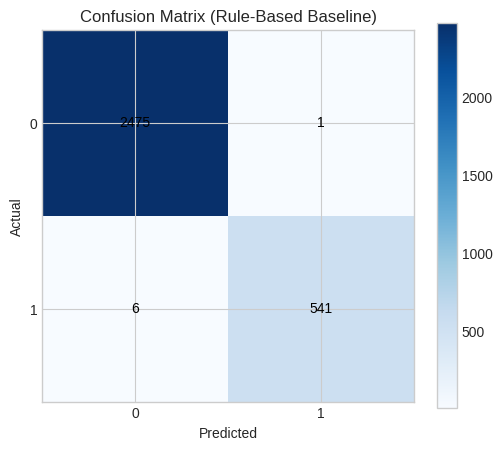

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')
ax.set_title(f"Confusion Matrix ({best_model_name})")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha='center', va='center', color='black')

plt.colorbar(im)
plt.show()


## Probability and Uncertainty Analysis

Instead of only predicting `Flood` or `No Flood`, we also inspect the predicted probability of flood risk.

This is useful because:
- moderate risk months can be monitored even if they are below the final classification threshold
- high confidence predictions can be separated from uncertain cases
- spatial maps become more informative when they show graded risk rather than only binary outcomes


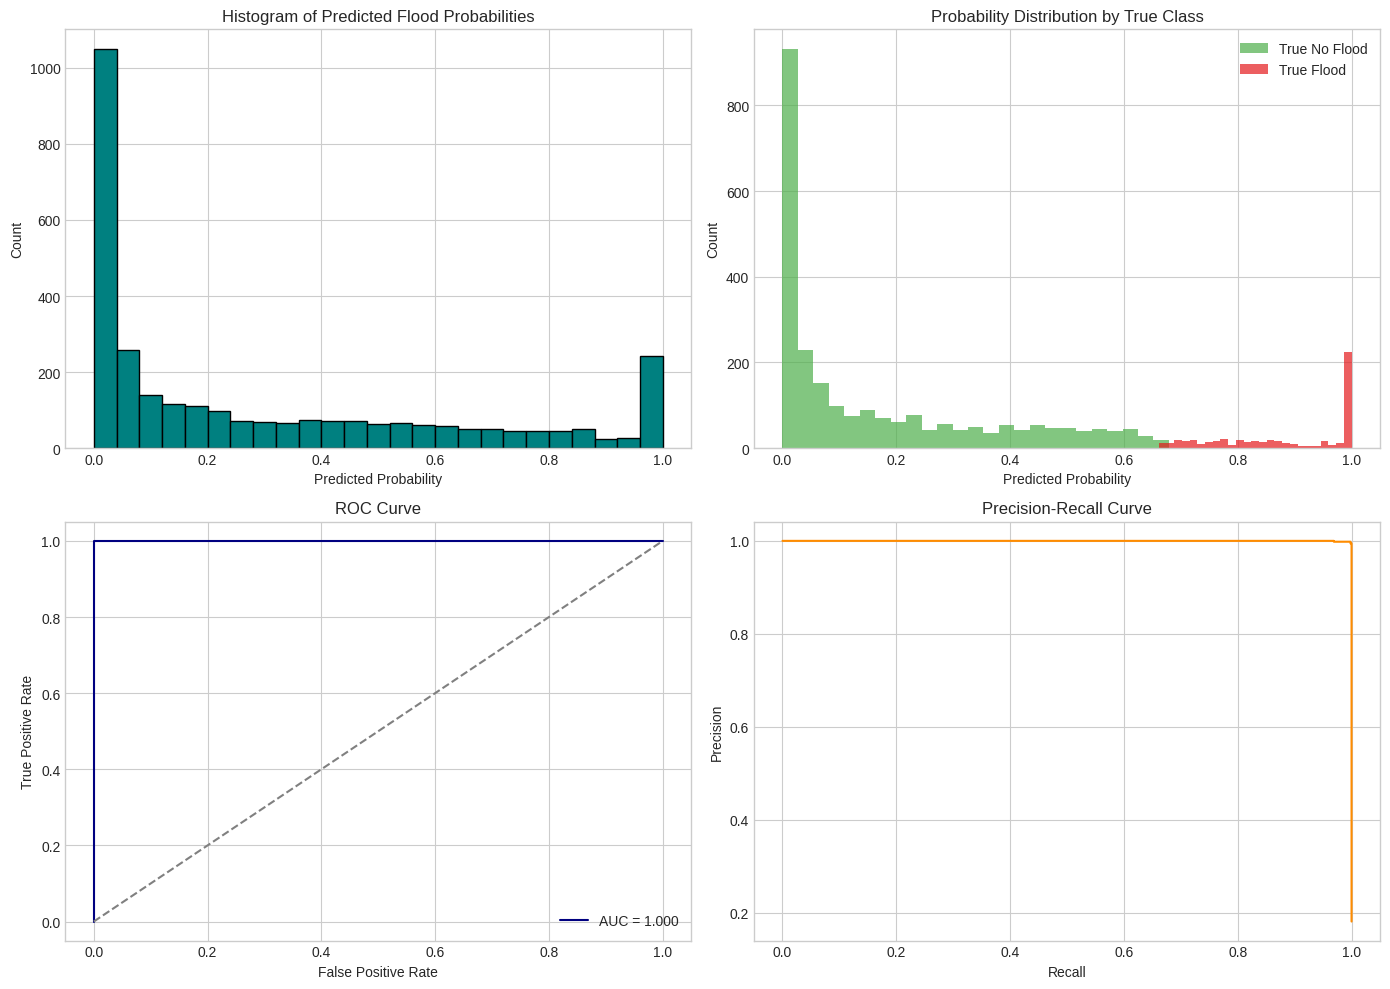

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(final_probs, bins=25, color='teal', edgecolor='black')
axes[0, 0].set_title("Histogram of Predicted Flood Probabilities")
axes[0, 0].set_xlabel("Predicted Probability")
axes[0, 0].set_ylabel("Count")

axes[0, 1].hist(final_probs[y_test.values == 0], bins=25, alpha=0.7, label='True No Flood', color='#4daf4a')
axes[0, 1].hist(final_probs[y_test.values == 1], bins=25, alpha=0.7, label='True Flood', color='#e41a1c')
axes[0, 1].set_title("Probability Distribution by True Class")
axes[0, 1].set_xlabel("Predicted Probability")
axes[0, 1].set_ylabel("Count")
axes[0, 1].legend()

fpr, tpr, _ = roc_curve(y_test, final_probs)
axes[1, 0].plot(fpr, tpr, label=f'AUC = {auc(fpr, tpr):.3f}', color='navy')
axes[1, 0].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[1, 0].set_title("ROC Curve")
axes[1, 0].set_xlabel("False Positive Rate")
axes[1, 0].set_ylabel("True Positive Rate")
axes[1, 0].legend()

precision, recall, _ = precision_recall_curve(y_test, final_probs)
axes[1, 1].plot(recall, precision, color='darkorange')
axes[1, 1].set_title("Precision-Recall Curve")
axes[1, 1].set_xlabel("Recall")
axes[1, 1].set_ylabel("Precision")

plt.tight_layout()
plt.show()


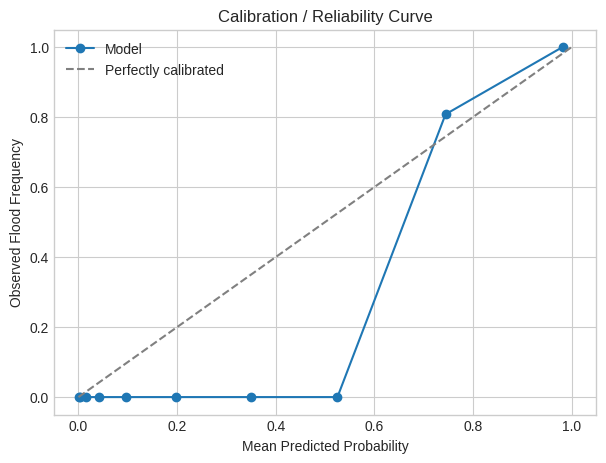

In [ ]:
prob_true, prob_pred = calibration_curve(y_test, final_probs, n_bins=10, strategy='quantile')

plt.figure(figsize=(7, 5))
plt.plot(prob_pred, prob_true, marker='o', label='Model')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly calibrated')
plt.title("Calibration / Reliability Curve")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Flood Frequency")
plt.legend()
plt.show()


## Spatial Mapping

- The map below shows average model estimated flood risk probability, not historical flood counts.  
- This means regions with higher values are places where the model tends to assign higher flood risk probability across their monthly observations.
- To add an uncertainty style view, we also map the standard deviation of predicted probabilities across time.  
- Higher spread means the region experiences more variation in model estimated risk.


In [ ]:
mapping = {
    "Andaman & Nicobar Islands": "Andaman and Nicobar",
    "Arunachal Pradesh": "Arunachal Pradesh",
    "Assam & Meghalaya": "Assam",
    "Bihar": "Bihar",
    "Chhattisgarh": "Chhattisgarh",
    "Coastal Andhra Pradesh": "Andhra Pradesh",
    "Coastal Karnataka": "Karnataka",
    "East Madhya Pradesh": "Madhya Pradesh",
    "West Madhya Pradesh": "Madhya Pradesh",
    "East Rajasthan": "Rajasthan",
    "West Rajasthan": "Rajasthan",
    "East Uttar Pradesh": "Uttar Pradesh",
    "West Uttar Pradesh": "Uttar Pradesh",
    "Gangetic West Bengal": "West Bengal",
    "Sub Himalayan West Bengal & Sikkim": "West Bengal",
    "Gujarat Region": "Gujarat",
    "Saurashtra & Kutch": "Gujarat",
    "Haryana Delhi & Chandigarh": "Haryana",
    "Himachal Pradesh": "Himachal Pradesh",
    "Jammu & Kashmir": "Jammu and Kashmir",
    "Jharkhand": "Jharkhand",
    "Kerala": "Kerala",
    "Konkan & Goa": "Goa",
    "Lakshadweep": "Lakshadweep",
    "Madhya Maharashtra": "Maharashtra",
    "Matathwada": "Maharashtra",
    "Vidarbha": "Maharashtra",
    "Naga Mani Mizo Tripura": "Manipur",
    "North Interior Karnataka": "Karnataka",
    "South Interior Karnataka": "Karnataka",
    "Orissa": "Orissa",
    "Punjab": "Punjab",
    "Rayalseema": "Andhra Pradesh",
    "Tamil Nadu": "Tamil Nadu",
    "Telangana": "Telangana",
    "Uttarakhand": "Uttaranchal"
}


In [ ]:
geojson_url = "https://raw.githubusercontent.com/geohacker/india/master/state/india_telengana.geojson"
r = requests.get(geojson_url, timeout=30)
r.raise_for_status()

with open("india.geojson", "wb") as f:
    f.write(r.content)

import geopandas as gpd
india_map = gpd.read_file("india.geojson")

if final_model is None:
    df_model['PROB'] = (
        df_model['RAINFALL'] /
        df_model['SUBDIVISION'].map(train_thresholds).fillna(global_threshold).replace(0, np.nan)
    ).clip(lower=0, upper=1.5).fillna(0) / 1.5
else:
    df_model['PROB'] = final_model.predict_proba(df_model[feature_columns])[:, 1]

risk_map = df_model.groupby('SUBDIVISION').agg(
    PROB=('PROB', 'mean'),
    PROB_STD=('PROB', 'std'),
    HIGH_RISK_SHARE=('PROB', lambda x: (x >= 0.7).mean())
).reset_index()

risk_map['PROB_STD'] = risk_map['PROB_STD'].fillna(0)
risk_map['STATE'] = risk_map['SUBDIVISION'].replace(mapping)

unmatched = risk_map.loc[~risk_map['STATE'].isin(india_map['NAME_1']), 'SUBDIVISION'].unique()
print("Unmatched subdivisions:", unmatched)


Unmatched subdivisions: []


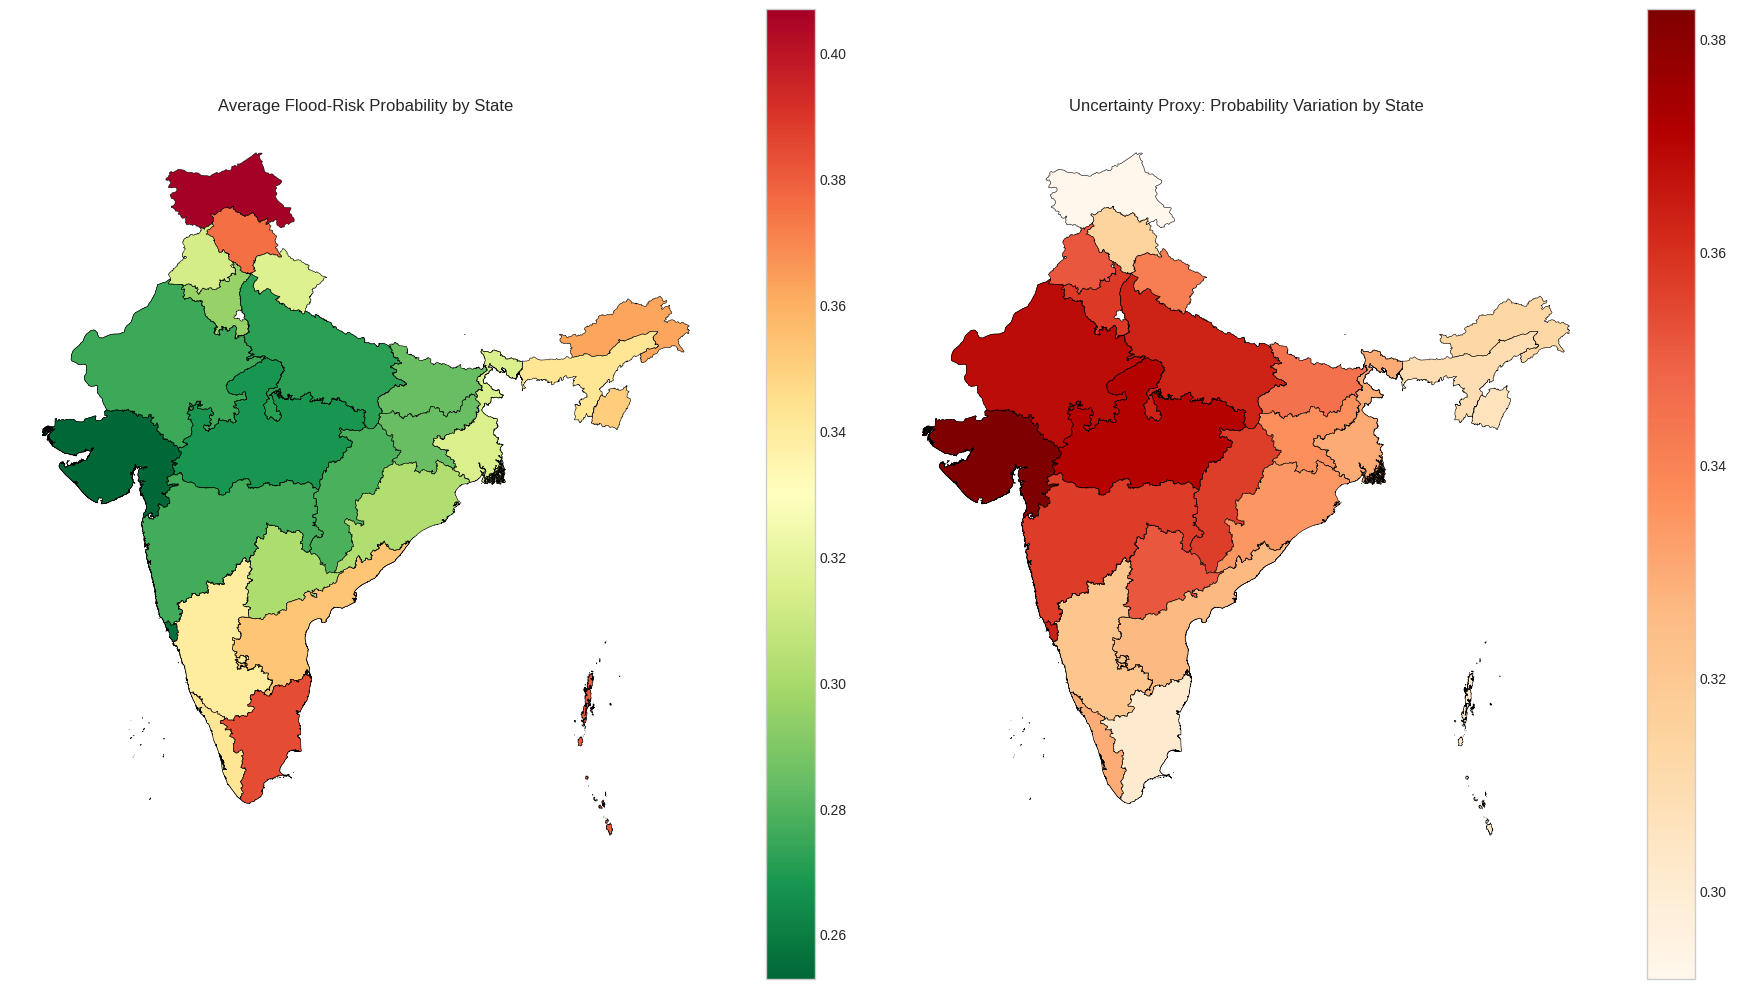

In [ ]:
merged = india_map.merge(risk_map, left_on='NAME_1', right_on='STATE')

fig, axes = plt.subplots(1, 2, figsize=(18, 10))

merged.plot(
    column='PROB',
    cmap='RdYlGn_r',
    legend=True,
    edgecolor='black',
    linewidth=0.4,
    ax=axes[0]
)
axes[0].set_title("Average Flood-Risk Probability by State")
axes[0].axis('off')

merged.plot(
    column='PROB_STD',
    cmap='OrRd',
    legend=True,
    edgecolor='black',
    linewidth=0.4,
    ax=axes[1]
)
axes[1].set_title("Uncertainty Proxy: Probability Variation by State")
axes[1].axis('off')

plt.tight_layout()
plt.show()


## Prediction Function

The function below keeps the same user interface as the original notebook:
- rainfall
- month
- year
- subdivision name

 Because the upgraded model now expects temporal features, the function fills missing lag/rolling inputs using historical subdivision-month averages from the training data.This keeps the demo simple while still allowing us to use the stronger temporal model.


In [ ]:
historical_profiles = train_df.groupby(['SUBDIVISION', 'MONTH']).agg({
    'RAINFALL_LAG_1': 'mean',
    'RAINFALL_LAG_2': 'mean',
    'RAINFALL_LAG_3': 'mean',
    'RAINFALL_LAG_12': 'mean',
    'RAINFALL_ROLL_3': 'mean',
    'RAINFALL_ROLL_6': 'mean'
}).reset_index()

overall_profile = train_df[[
    'RAINFALL_LAG_1', 'RAINFALL_LAG_2', 'RAINFALL_LAG_3',
    'RAINFALL_LAG_12', 'RAINFALL_ROLL_3', 'RAINFALL_ROLL_6'
]].mean()

def predict_flood(rainfall, month, year, subdivision_name):
    if subdivision_name not in le.classes_:
        raise ValueError(f"Unknown subdivision: {subdivision_name}")

    match = historical_profiles[
        (historical_profiles['SUBDIVISION'] == subdivision_name) &
        (historical_profiles['MONTH'] == month)
    ]

    if match.empty:
        profile = overall_profile
    else:
        profile = match.iloc[0]

    subdivision_encoded = le.transform([subdivision_name])[0]
    monsoon = int(month in [6, 7, 8, 9])
    lag_1 = float(profile['RAINFALL_LAG_1'])
    lag_2 = float(profile['RAINFALL_LAG_2'])
    lag_3 = float(profile['RAINFALL_LAG_3'])
    lag_12 = float(profile['RAINFALL_LAG_12'])
    roll_3 = float(profile['RAINFALL_ROLL_3'])
    roll_6 = float(profile['RAINFALL_ROLL_6'])
    change_1 = rainfall - lag_1

    input_df = pd.DataFrame([{
        'RAINFALL': rainfall,
        'MONTH': month,
        'YEAR': year,
        'SUBDIVISION_ENC': subdivision_encoded,
        'MONSOON': monsoon,
        'RAINFALL_LAG_1': lag_1,
        'RAINFALL_LAG_2': lag_2,
        'RAINFALL_LAG_3': lag_3,
        'RAINFALL_LAG_12': lag_12,
        'RAINFALL_ROLL_3': roll_3,
        'RAINFALL_ROLL_6': roll_6,
        'RAINFALL_CHANGE_1': change_1
    }])

    if final_model is None:
        threshold = train_thresholds.get(subdivision_name, global_threshold)
        prob = float(np.clip((rainfall / max(threshold, 1e-6)) / 1.5, 0, 1))
    else:
        prob = float(final_model.predict_proba(input_df)[0][1])

    if prob < 0.30:
        risk = "LOW"
    elif prob < 0.70:
        risk = "MEDIUM"
    else:
        risk = "HIGH"

    return prob, risk


In [ ]:
example_cases = [
    (200, 7, 2025, "Gangetic West Bengal"),
    (200, 7, 2025, "Haryana Delhi & Chandigarh")
]

for rainfall, month, year, subdivision_name in example_cases:
    prob, risk = predict_flood(rainfall, month, year, subdivision_name)
    print(f"{subdivision_name}: probability = {prob:.3f}, risk = {risk}")


Gangetic West Bengal: probability = 0.531, risk = MEDIUM
Haryana Delhi & Chandigarh: probability = 1.000, risk = HIGH




### Key findings
This project demonstrates that incorporating temporal features—such as lagged rainfall, rolling averages, and short-term changes—significantly improves the realism of the flood-risk formulation compared to relying only on current rainfall and basic time variables. Flood risk is inherently influenced by recent rainfall accumulation, and capturing this temporal dependency leads to a more meaningful representation of the problem.

The comparison with a simple rule-based baseline highlights an important insight: it allows us to critically assess whether more complex machine learning models genuinely provide additional value beyond straightforward rainfall-threshold rules. This comparison strengthens the validity of the analysis by ensuring that improvements are not assumed but empirically tested.

Furthermore, the use of probabilistic predictions and spatial mapping enhances interpretability. Instead of limiting the output to binary flood/no-flood labels, probability estimates and geographic visualizations provide a more nuanced understanding of risk, making the results more useful for real-world decision-making and planning..

### Limitations
Despite its strengths, the project has several limitations. The most important is that the target variable is a rainfall-based proxy for flood risk, rather than a dataset of actual observed flood events. As a result, the model predicts high rainfall conditions associated with flooding, not confirmed flood occurrences.

Additionally, the spatial analysis is conducted at the subdivision or state level, which may mask local variations in flood behavior. Flood dynamics can vary significantly within smaller geographic areas, and this level of aggregation limits the model’s ability to capture such fine-grained patterns.

### Future work
There are several directions for improving and extending this work. Incorporating observed flood event data would make the prediction task more accurate and directly aligned with real-world outcomes.

The model could also be enhanced by integrating additional environmental and hydrological variables such as river discharge, elevation, drainage density, soil moisture, and land use, all of which play a crucial role in flood generation.

Finally, exploring more advanced approaches, including time-series models and spatio-temporal machine learning techniques, could further improve predictive performance and better capture both temporal dependencies and spatial relationships.

### Takeaways
- Incorporating temporal features leads to a more realistic and meaningful flood-risk model.
- Comparing against simple baselines is essential to validate the true value of complex machine learning models.
- Probabilistic predictions and spatial maps provide richer and more actionable insights than binary classifications alone.


In [ ]:
import joblib
import os

os.makedirs("models", exist_ok=True)

joblib.dump(final_model,
            "models/flood_model.pkl")

joblib.dump(le,
            "models/label_encoder.pkl")

joblib.dump(historical_profiles,
            "models/historical_profiles.pkl")

joblib.dump(overall_profile,
            "models/overall_profile.pkl")

joblib.dump(train_thresholds,
            "models/train_thresholds.pkl")

joblib.dump(global_threshold,
            "models/global_threshold.pkl")

print("Saved successfully")